# Capstone — EMG gesture (Ninapro DB1) · two eval modes

### Real-data capstone companion · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/track_emg_ninapro.ipynb) [![nbviewer](https://img.shields.io/badge/view-nbviewer-orange)](https://nbviewer.org/github/farhad-abtahi/CM2013/blob/main/notebooks/track_emg_ninapro.ipynb) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=track_emg_ninapro.ipynb)

> **Motivating question.** Why does a hand-gesture classifier that scores 0.78 *within* a subject collapse to 0.19 on a *new* subject — and how would you show a leaky split faking a high score?

## What this notebook demonstrates

- Ninapro DB1 surface-EMG end-to-end (direct zip; cite Atzori 2014).
- **Two evaluation modes** — within-subject vs new-subject — side by side.
- A **wrong-then-right** leakage demo: a random window split inflates the score.
- DB1 is a rectified *envelope* (no zero-crossings) — know your signal.

## Runs in

| Platform | Status |
|---|---|
| **nbviewer / GitHub / CI** | full pipeline on **synthetic** data (no network) |
| **Google Colab** | set `USE_REAL = True` for the real download |
| **JupyterLite** | synthetic path only |

**Split unit:** **subject / repetition**.  **Default metric:** macro-F1 (both modes).  *Each subject zip is ~20 MB; 5 subjects download in ~20 s.*

## 0 · Background & literature review (do this first — course outcome L5)

**Course refresher:** EMG signature §1.4 · rectified/analytic **envelope §5.5** · time-domain features (MAV/RMS/WL/VAR) §11.3 · mean/median frequency Ch7 · within- vs cross-subject = **domain shift §12.3/§12.13**. **Anchors:** Atzori et al. (2014); **Hudgins** feature set (1993); Phinyomark (2012).

**Guiding questions your report must answer** (motivate your design — see [`tracks/BACKGROUND_MAP.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/BACKGROUND_MAP.md)):

- Which time-domain features are the standard Hudgins set, and why do they work on EMG?
- Why does within-subject accuracy collapse across subjects (electrode shift)?
- What is 'electrode shift' and how does the field mitigate it (calibration, adaptation)?

In [1]:
%matplotlib inline
import sys, os, subprocess

def _add_paths(root):
    for sub in ("tracks", "src", "src/bsp"):
        p = os.path.join(root, sub)
        if os.path.isdir(p):
            sys.path.insert(0, os.path.abspath(p))

# Local checkout: repo root is the parent of notebooks/ (or the cwd itself).
_add_paths(".."); _add_paths(".")
try:
    from emg_ninapro import EMGNinaproTrack
    import bookstyle as bs   # shared plotting style
except Exception:
    if "google.colab" in sys.modules:
        # imbalanced-learn is NOT pre-installed in a fresh Colab runtime, and the
        # decision-points A/B below runs cfg={"imbalance": "smote"} -- so it goes
        # in here, not in a comment, or that cell raises ImportError on first run.
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "scipy", "scikit-learn", "imbalanced-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    _add_paths("_bsp_repo")
    from emg_ninapro import EMGNinaproTrack
    import bookstyle as bs

import numpy as np
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules
# SYNTHETIC by default so nbviewer / CI / JupyterLite render WITHOUT network.
# Set USE_REAL = True in Colab to download and run the real dataset.
USE_REAL = IN_COLAB and False
print("environment :", "colab" if IN_COLAB else sys.platform)
print("USE_REAL    :", USE_REAL, "(synthetic fallback renders offline)")


environment : darwin
USE_REAL    : False (synthetic fallback renders offline)


## ✍️ Predict before you run

Predict **both** numbers: within-subject macro-F1 and new-subject macro-F1. How big will the gap be? And what will a **leaky** random-window split report — closer to which one?

*Write your prediction down now. The point is to be surprised when you are wrong — that is where the intuition forms.*

## 1 · Get the data (real or synthetic)

In [2]:
track = EMGNinaproTrack()
if USE_REAL:
    cache = os.path.join('..', 'data_cache', 'emg_ninapro') if os.path.isdir('../data_cache') else 'data_cache/emg_ninapro'
    track.download(cache, subset=range(1, 6)); recs = track.load(cache)
else:
    recs = track.smoke()
print('subjects:', len(recs), '| windows:', sum(len(r.labels) for r in recs),
      '| gestures:', len(set(l for r in recs for l in r.labels)))

subjects: 5 | windows: 1440 | gestures: 12


## 2 · The two-mode result — the whole lesson

`evaluate_modes()` runs **within-subject** (leave-repetitions-out) and **new-subject** (leave-one-subject-out). Watch the gap.

within_subject  macro-F1 = 0.835
new_subject     macro-F1 = 0.334
  within_subject  spread: mean macro_f1 0.834 (sd 0.103, range 0.676-0.965 across 5 subjects)
  new_subject     spread: mean macro_f1 0.303 (sd 0.114, range 0.108-0.407 across 5 subjects)


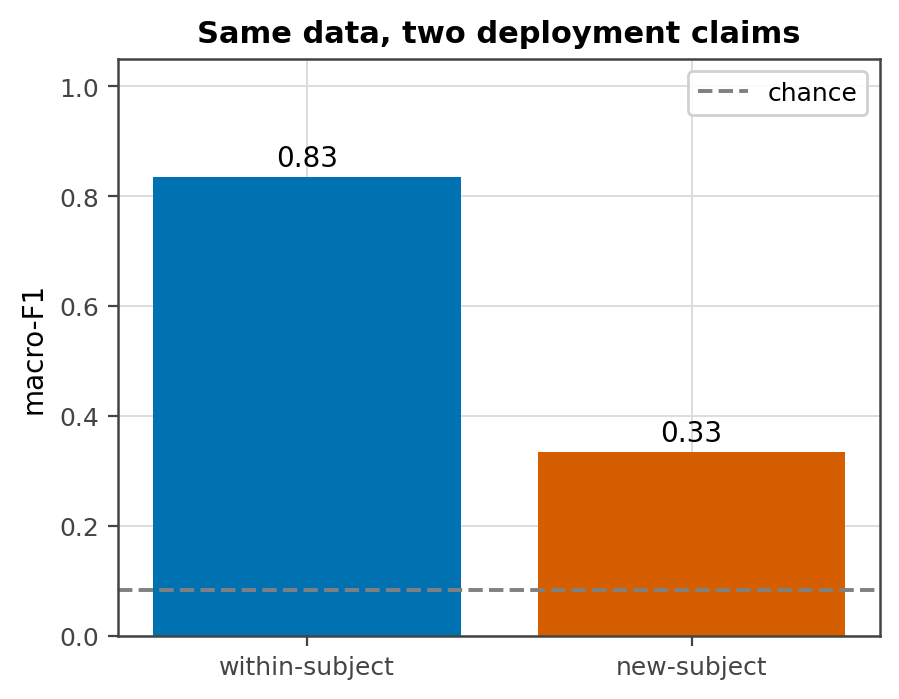

In [3]:
modes = track.evaluate_modes(recs)
from sklearn.metrics import f1_score
vals = {k: f1_score(v['y_true'], v['y_pred'], average='macro') for k, v in modes.items()}
for k, v in vals.items(): print(f'{k:15s} macro-F1 = {v:.3f}')
for k, v in modes.items(): print(f'  {k:15s} spread:', v['summary'])
fig, ax = plt.subplots(figsize=(4.6, 3.6))
ax.bar(['within-subject', 'new-subject'], [vals['within_subject'], vals['new_subject']], color=['C0', 'C3'])
for i, v in enumerate([vals['within_subject'], vals['new_subject']]): ax.text(i, v+0.02, f'{v:.2f}', ha='center')
ax.axhline(1/len(track.meta.classes), ls='--', color='gray', label='chance')
ax.set_ylabel('macro-F1'); ax.set_ylim(0, 1.05); ax.legend(); ax.set_title('Same data, two deployment claims')
plt.tight_layout(); plt.show()

## 3 · Wrong-then-right — how a leaky split lies

Now split windows **randomly**, ignoring subject and repetition. Overlapping windows from the same repetition land on both sides — the model memorises the *person*, not the *gesture*, and the score inflates.

In [4]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import f1_score
X, y, subj, rep = track._build(recs)
leaky = cross_val_predict(track.baseline(), X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0))
leak_f1 = f1_score(y, leaky, average='macro')
print(f'LEAKY  random-window split : macro-F1 = {leak_f1:.3f}   <-- looks great, is a LIE')
print(f'HONEST new-subject  split  : macro-F1 = {vals["new_subject"]:.3f}   <-- the real deployment number')
print('The gap is the size of the lie. Always split by the leakage unit you will deploy across.')

LEAKY  random-window split : macro-F1 = 0.842   <-- looks great, is a LIE
HONEST new-subject  split  : macro-F1 = 0.334   <-- the real deployment number
The gap is the size of the lie. Always split by the leakage unit you will deploy across.


## Read the number against a yardstick

**Yardstick:** DB1 within-subject **~0.75–0.90** (Hudgins features); cross-subject has no strong ceiling and stays low without adaptation. The synthetic cohort here rolls each subject's electrode positions by up to ±2 channels and gives every *repetition* its own shared gain — so the two-mode gap and the leakage demo below are real effects, not decoration.

Accuracy hides class imbalance — always read **κ / macro-F1 / the confusion matrix** together, and state the **split unit** with every number.

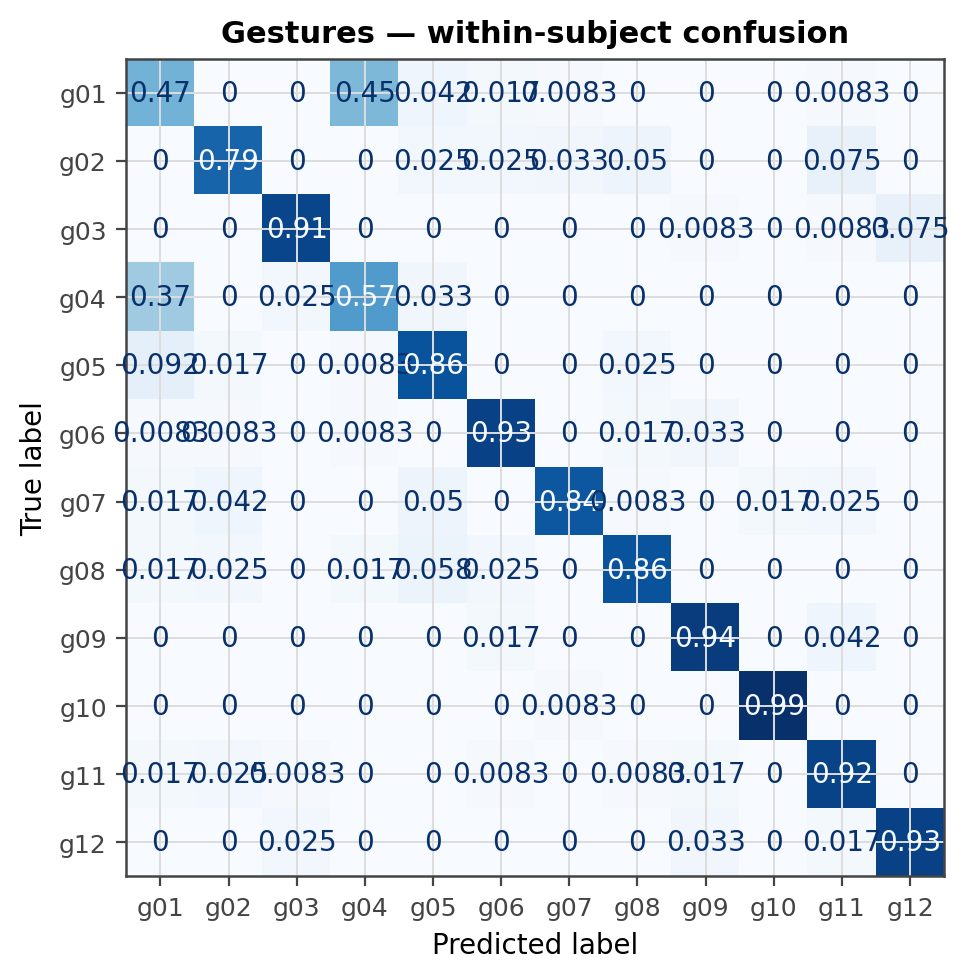

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
w = modes['within_subject']
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(w['y_true'], w['y_pred'], labels=track.meta.classes,
        normalize='true', cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Gestures — within-subject confusion'); plt.tight_layout(); plt.show()

## Decision points on this track — the menus you are choosing from

Everything below is a **menu, not a recipe.** `tracks/adapter.py` ships options *with their trade-offs* and no blessed answer; picking one, measuring what it cost or earned, and writing down why is the work the rubric grades (criteria 2 and 5). Below, after one warning you should read first, a cell runs a few of them side by side so you can see that the numbers actually move.

Every option listed here is one **this track's adapter actually reads** — the notebook is generated from the track's own `SUPPORTED_CFG_KEYS`, so nothing below is a decoration.

> **What is *not* on this track's menu — and why that is itself a finding.**
>
> * **Stage 2 — the Chapter 8 denoise menu** (`cfg["impulsive"]`, `"baseline"`, `"powerline"`, `"broadband"`): EMG's preprocess() is an identity stub. The stage-2 move that attacks this track's cross-subject gap is per-channel normalisation WITHIN a subject (i.e. a calibration procedure you must then declare) — write it, then register its knobs with track.declare_cfg_keys(...).
>
> * **Stage 3 — the Chapter 7 spectral-estimator menu** (`cfg["spectral_method"]`): EMG's features are MAV / RMS / waveform length / variance plus a mean frequency taken from an rFFT magnitude spectrum — nothing here integrates a PSD, so there is no spectral estimator to choose.
>
> The scaffold **refuses** these keys here (`UnsupportedCfgKey`) rather than accepting and ignoring them, because an option that silently does nothing teaches the opposite of what this section is for. If you implement the stage that would read one — a CSP filter, a real `preprocess()`, a PSD-based feature — register its knobs with `track.declare_cfg_keys(...)` and the option becomes real. Every track reads `cfg["select"]` and `cfg["imbalance"]`: those two menus are owned by the shared harness, so they work everywhere.

### Stage 2 — preprocessing · *this track's `preprocess()` is a stub you fill in*

DB1 ships a rectified, low-pass **envelope**, so the usual raw-sEMG moves (zero crossings, slope-sign changes) are meaningless here — knowing that is half the exercise.

| choice | buys you | costs you |
|---|---|---|
| **per-channel normalisation within a subject** (e.g. divide by that subject's max-voluntary or median activation) | directly attacks the cross-subject gap: gains and electrode contact stop mattering | needs a calibration contraction — you have now defined a deployment procedure, so say so |
| extra envelope smoothing | steadier amplitude features | slower response; blurs the onset that separates short gestures |
| window length (200 ms as shipped) | shorter = more responsive controller | longer = more stable features; a prosthesis has a latency budget, name yours |
| channel re-ordering / spatial normalisation | can partly undo electrode rotation | you must estimate the rotation from data — and estimating it using the test subject's labels is a leak |
| drop the transition windows at gesture onset | cleaner labels | you have removed exactly the windows a real controller must classify |

### Stage 4 — feature selection · `cfg["select"]`, `cfg["select_k"]`, `cfg["select_C"]`

| `select` | Family | Picks features by | Good when | Watch out |
|---|---|---|---|---|
| `"none"` *(default)* | — | keeps everything | few features vs. many samples; you want the model to arbitrate | irrelevant features dilute distance-based learners |
| `"variance"` | filter | dropping near-constant columns | a cheap sanity pass | says nothing about relevance to `y` |
| `"anova"` | filter | univariate F-test vs. the label | fast and stable on tiny folds | blind to feature *interactions* |
| `"mutual_info"` | filter | non-linear dependence with the label | non-monotonic relations | noisier estimate; wants more samples |
| `"tree"` | embedded | forest impurity importance | interactions matter | biased toward continuous/high-cardinality features; **splits credit** between correlated features so near-duplicates survive together |
| `"lasso"` | embedded | L1-penalised linear SVM — coefficients driven to **exactly zero** | you want genuine sparsity and a short, defensible feature list; redundant correlated features should be *eliminated* | assumes roughly **linear** separability; among two correlated features L1 keeps one near-arbitrarily, so **check the surviving set is stable across folds** before calling it "the" feature set |

**`"tree"` vs `"lasso"` is the contrast worth running.** Both are *embedded*, so both see interactions a univariate filter cannot. But on correlated features they behave oppositely: a forest **splits the credit** (two near-duplicate band powers each get half the importance and both survive), while L1 **picks one and zeroes the other** (a second copy of an already-used feature buys no likelihood and costs penalty). `"tree"` gives you a ranking with the redundancy intact; `"lasso"` gives you a genuinely short list. `select_C` is the L1 strength — *smaller C = fewer surviving features* — and it is a number you must report.

**`select_k` is clamped to this track's feature count, out loud.** The default `select_k = 20` is larger than the feature count on four of the six tracks, so a naive first experiment would keep every feature and quietly teach you that selection does nothing. The harness now says so — watch for the `[Track] select=...` line and check `rep["notes"]`. The two **embedded** options ignore `select_k` entirely: how many features survive is a *result*, and the harness prints it.

### Stage 5 — class imbalance · `cfg["imbalance"]`, `cfg["threshold"]`

The supplied baseline uses `class_weight="balanced"`. That is a **default, not a recommendation**, and the rubric grades how you addressed imbalance — so make it a choice you can defend:

| `imbalance` | What it does | Watch out |
|---|---|---|
| `"none"` | plain majority vote | the rare class can be predicted almost never while accuracy still looks fine |
| `"balanced"` *(default)* | per-class weights ∝ 1/frequency | amplifies noisy minority rows too; probabilities stop being calibrated |
| `"balanced_subsample"` | as above, recomputed per tree | forest-specific |
| `"resample"` | random over-sampling **inside `fit`** | duplicated rows invite overfitting — and outside the fold it is a *leak* |
| `"smote"` | **synthetic** minority rows, interpolated between a real sample and one of its k nearest minority neighbours (fold-safe, inside `fit`) | a point halfway between two epochs is a claim about feature space, **not about physiology** — interpolate between two different patients, or an N2 and an N3 epoch, and you have manufactured a body that does not exist. On these small cohorts that risk is live |
| `"adasyn"` | as `"smote"`, concentrated where the minority is hardest to classify | densifies exactly the contested boundary, so mislabelled or artifactual minority rows get amplified most |
| `"threshold"` | move the operating point on the minority class | you must report the threshold; tuning it on test data is as dishonest as a leak |

**The distinction to state in your report:** `"balanced"` never adds a row, it changes how much each existing row *counts*. `"resample"` adds exact copies, so the minority region gets heavier but not one millimetre wider. `"smote"` adds **new points in feature space**, so the region genuinely expands and the boundary is pushed rather than weighted — which is the whole benefit and the whole danger. If you use it, say what a synthetic minority sample *means* on your track, and be honest if the answer is "nothing physiological".

Doing nothing is a defensible answer *if you say you looked and why you left it*. A silent default is worth no marks.

> **Two things the wrapper does for you, and both are worth understanding.** `"resample"`, `"smote"` and `"adasyn"` are all applied **inside `fit`**, so they are redone per fold on training rows only — resampling before the split puts copies (or interpolations) of the test rows into the training set and the score becomes fiction. And SMOTE/ADASYN run **after** the pipeline's `StandardScaler` (`scale → resample → clf`), because "k nearest minority neighbours" is a statement about *distance*: search in raw units and whichever feature happens to be measured in the largest numbers picks the neighbours, regardless of physiological similarity. In Colab the setup cell installs `imbalanced-learn` for you; every other option on this menu is sklearn-only.

### Read downstream symptoms **backwards**, to the stage that caused them

The reflex when a number disappoints is to retune the classifier (stage 5). It is usually the wrong stage. Diagnose upwards:

| What the report shows | The tempting fix | Where the cause usually is |
|---|---|---|
| **Worst-subject metric far below the mean** (check `rep['summary']` and `rep['spread_rows']`) | more trees, deeper trees | **Stage 2 — preprocessing.** A per-recording normalisation, a different band, or artifact handling. A feature that means different things in different subjects cannot be rescued by a classifier. Then **stage 4**: a selector fit on a majority of easy subjects can drop the only feature the hard one needed. |
| **Good pooled metric, one class near-zero recall** | accept it; the average looks fine | **Stage 5 — imbalance handling** first (the menu above), then **stage 3**: if no feature actually describes that class, no weighting invents one. |
| **Feature selection changed nothing at all** | conclude selection is useless here | **`select_k` ≥ your feature count** — the harness prints a note saying exactly this. Lower `select_k` before drawing any conclusion. |
| **A leaky split scores far above the honest one** | quietly report the higher number | **Validation, stage 1.** The split unit is the deployment claim. This gap is the size of the lie. |
| **Train ≫ test, and the spread across groups is huge** | regularise the model | **Stage 3 — feature extraction.** Too many features for the number of *independent groups* (not rows). Fewer, better-motivated features beat more regularisation. |

> **Log it.** Copy [`tracks/results_log_TEMPLATE.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/results_log_TEMPLATE.md) into your team repo as `RESULTS.md` and add a row per iteration *plus* a decision-log row per choice above. Rubric **Criterion 9 — Iteration & revision history** is graded from that file, and it specifically asks for at least one decision you went back and **revised because of a downstream result** — not just more iterations forward.

### ⚠️ Read this **before** you run the next cell

**Comparing many options against the same folds is itself a way to overfit.** The cell below scores several design choices on the *same* group-aware folds — and those are the same folds that will produce the number you report. No individual run leaks a subject; the harness guarantees that. But if you try twelve configurations against one held-out set and then report the best, the winner is chosen partly because it suits *these particular subjects*, and its margin over the runner-up is optimistically biased. This is the **garden of forking paths**: the leak is not in any one fold, it is in the *selection* you perform across many of them. It gets worse the more you look, and it is invisible — the report comes out looking exactly like an honest one.

Which is why this warning is here rather than under the results: the decisions that fix it can only be made **before you know which option won**. Take one minute now and write down:

1. **How many configurations you will compare** — a handful, not a sweep. Put the list in `RESULTS.md` *before* you run it, and report the count in your report.
2. **Whether you are holding out a DEV set** — a few groups set aside up front, so the comparison and the final number do not come from the same folds.
3. **What you will count as a difference** — a margin smaller than the spread across subjects (the `worst / best` columns the cell prints) is *no difference*, not a win.

The trade-offs of those two approaches are laid out in full just after the cell. Read them now if you want the argument first; the point is that the choice between them is only honest while you still cannot see the table.

In [6]:
# A/B the SAME honest harness under different design choices. None of these is
# "the answer" -- the point is that the numbers MOVE, so the choice is a real one
# with a consequence you can measure and defend.
X, y, groups = track.build_dataset(recs)
PRIMARY = track.meta.default_metrics[0]

options = [
    ('supplied baseline', {}),
    ('select=anova, default k=20 (of 50)', {'select': 'anova'}),
    ('select=anova, k=35', {'select': 'anova', 'select_k': 35}),
    ('select=anova, k=10', {'select': 'anova', 'select_k': 10}),
    ('select=tree', {'select': 'tree'}),
    ('select=lasso (L1, C=1.0)', {'select': 'lasso'}),
    ('select=lasso (L1, C=0.05)', {'select': 'lasso', 'select_C': 0.05}),
    ('imbalance=none', {'imbalance': 'none'}),
    ('imbalance=smote', {'imbalance': 'smote'}),
]
rows, unit = [], None
for name, c in options:
    c = dict(c)
    # a PREPROCESSING choice changes the features themselves, so stages 2-3 must
    # re-run; a selection/imbalance choice only changes stages 4-5 inside the folds.
    if c.pop("rebuild", False):
        Xc, yc, gc = track.build_dataset(recs, cfg=c)
    else:
        Xc, yc, gc = X, y, groups
    r = track.evaluate(Xc, yc, gc, cfg=c)
    sp = r["spread"].get(PRIMARY, {})
    unit = r["spread_unit"]      # subject / record / fold -- whichever the metric is defined on
    rows.append((name, r[PRIMARY], sp.get("min", float("nan")), sp.get("max", float("nan"))))

print(f"\n{'design choice':<38} {PRIMARY:>12}   worst / best {unit}")
print("-" * 82)
for name, val, lo, hi in rows:
    print(f"{name:<38} {val:>12.3f}   {lo:.3f} / {hi:.3f}")

print("\nHarness notes (things it refuses to hide):")
for n in track.notes or ["(none)"]:
    print("  *", n)

[EMGNinaproTrack] select='anova': keeping 20 of 50 features (30 dropped per training fold).
[EMGNinaproTrack] select='anova': keeping 35 of 50 features (15 dropped per training fold).
[EMGNinaproTrack] select='anova': keeping 10 of 50 features (40 dropped per training fold).
[EMGNinaproTrack] select='tree': kept 25 of 50 features above the importance threshold (a forest SPLITS credit between correlated features, so near-duplicates tend to survive together — contrast select='lasso').
[EMGNinaproTrack] select='lasso' (C=1.0): L1 kept 50 of 50 features with a non-zero coefficient (0 zeroed per training fold). Re-fit on another fold the surviving set may differ — L1 picks ONE of each correlated pair, so check the stability before calling this 'the' feature set.
[EMGNinaproTrack] select='lasso' (C=0.05): L1 kept 50 of 50 features with a non-zero coefficient (0 zeroed per training fold). Re-fit on another fold the surviving set may differ — L1 picks ONE of each correlated pair, so check the 

The A/B above runs the **new-subject** split — the honest deployment number — so the column is small and the differences between selectors are small with it. That is itself the finding: **no stage-4 or stage-5 choice fixes a domain shift.** The cross-subject gap is caused upstream, by features that encode *which electrode* rather than *which gesture*, so the fix lives in stage 2 (per-subject normalisation) or stage 3 (rotation-invariant features). Try one, put both numbers in `RESULTS.md`, and say which mode each belongs to — Criterion 8 exists precisely to catch a report that quotes only the flattering one.

### Now you have the table — two things it does *not* protect you from

**1 · The forking-paths problem you were warned about, in full.**
Every row in that table was scored on the *same* group-aware folds — and those are the same folds that will produce the number you report. A dozen comparisons on a cohort of five subjects is a lot of selection pressure on very little data.

Two defensible ways to handle it, either of which is worth marks if you say which you used:

| approach | what you do | what it costs |
|---|---|---|
| **a separate development set** | hold out a few groups *up front* as a DEV set, compare every design option on DEV only, then run the winner **once** on the untouched evaluation folds and report that number | fewer groups for both purposes — painful on the small cohorts here, and the DEV estimate is noisy |
| **a comparison budget** | decide in advance how many configurations you will compare (a handful, not a sweep), write them into `RESULTS.md` *before* you run them, and report the count | you may miss a better option; you must resist re-opening the budget after seeing the numbers, which is the whole discipline |

Whichever you choose, **report the number of configurations you compared**, and read a small margin (a couple of points, inside the per-group spread) as *no difference* rather than as a win. A difference smaller than the spread across subjects is not a result. If you have just run the cell above without deciding any of this first, the honest move is to write down the count you have already spent and adopt a budget from here on — not to keep comparing until something wins.

**2 · Features here are built BEFORE the folds are cut — which is safe only because nothing learns.** `build_dataset()` runs stages 2-3 over every recording once, and `evaluate()` splits afterwards. Every preprocessing option on the menus above is **stateless** (a fixed filter, or a threshold estimated from one epoch's own samples), so computing it before or inside the fold gives identical features and the ordering is purely a speed decision.

That stops being true the moment you add a stage that **learns from the data** — a **CSP** spatial filter, a PCA/ICA basis, a z-score whose mean and scale come from the pooled cohort, a learned artifact template. Fit any of those over all the recordings first and every held-out subject has already shaped the transform that built the training features. **The harness will not catch this**: `assert_no_subject_leak` checks group ids per fold, and it cannot see that a filter was learned from them, so the number comes out clean and wrong. A learned stage must be fit *inside* the fold — as a step in the `clf=` pipeline (cloned and refit per fold) or via `select_features()` — and you should say in `RESULTS.md` which you did.

### ⚠️ The one thing above that is **not** a menu — see the leak once

Every table above is a genuine choice you get to make and defend. **The validation scheme is not one.** The leakage-safe split — LOSO or GroupKFold on this track's declared split unit — is the only number that counts for your grade, and `TrackAdapter.evaluate()` enforces it on every fold with `assert_no_subject_leak`. There is no config key to turn it off, deliberately.

So why run the wrong one at all? Because **seeing the gap once is the fastest way to understand why.** The cell below scores this track's data twice: once with a naive random stratified 5-fold split that ignores the leakage unit entirely, and once with the honest group-aware split. Same features, same classifier, same metric. The only difference is *who is allowed to appear on both sides of the split* — and the difference between the two numbers is the size of the claim you would be making falsely.

Predict the gap before you run it.

In [7]:
# NOT A CHOICE. The honest split is the only one that counts for your grade --
# but seeing the gap once is the fastest way to understand why.
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from adapter import metrics_for

PRIMARY = track.meta.default_metrics[0]
X, y, groups = track.build_dataset(recs)          # rebuilt so this cell stands alone

# 1) THE LEAKY SPLIT -- random/stratified, blind to the leakage unit. Rows from the
#    same subject/record land on BOTH sides, so the model can recognise the person
#    instead of the phenomenon.
leaky_pred = cross_val_predict(track.baseline(), X, y,
                               cv=StratifiedKFold(5, shuffle=True, random_state=0))
leaky = metrics_for(y, leaky_pred)[PRIMARY]

# 2) THE HONEST SPLIT -- the scaffold's own group-aware LOSO / GroupKFold.
honest = track.evaluate(X, y, groups)[PRIMARY]

unit = track.meta.split_unit
rows_per_group = np.bincount(np.unique(groups, return_inverse=True)[1])
gap = leaky - honest
print(f"leaky  random 5-fold split      : {PRIMARY} = {leaky:.3f}   <-- NOT a deployment claim")
print(f"honest {unit + '-wise split':<24} : {PRIMARY} = {honest:.3f}   <-- the number that counts")
print(f"{'gap (the size of the lie)':<32} : {gap:+.3f}")
print(f"{'rows per ' + unit:<32} : max {rows_per_group.max()}, median {int(np.median(rows_per_group))}")
print()

if rows_per_group.max() == 1:
    print(f"READ IT HONESTLY: on this track every {unit} contributes exactly ONE row, so a random")
    print(f"  split CANNOT put the same {unit} on both sides. There is structurally nothing to")
    print( "  leak here, and the gap is expected to be ~0 (what you see is just fold-composition")
    print( "  noise, and it can even come out negative). This is not evidence that leakage is a")
    print( "  non-issue in biosignals -- it is this track's granularity making it impossible.")
    print(f"  The tracks with many epochs per {unit} are where the gap opens up; go look at one.")
elif gap >= 0.05:
    print(f"READ IT HONESTLY: each {unit} contributes up to {rows_per_group.max()} rows, so a random split")
    print(f"  scatters one {unit}'s rows across train AND test. The model scores partly by")
    print(f"  recognising the {unit} -- which at deployment is a {unit} it has never seen.")
    print(f"  That {gap:+.3f} is the size of the claim you would be making falsely.")
else:
    print(f"READ IT HONESTLY -- and this is the interesting case. Each {unit} contributes up to")
    print(f"  {rows_per_group.max()} rows, so a leak WAS structurally possible, and yet the gap is only {gap:+.3f}.")
    print( "  The tempting conclusion ('leakage does not matter here') is the wrong one. What a")
    print(f"  near-zero gap actually says is that the current features carry little {unit}-specific")
    print( "  structure for the model to memorise -- which, when the honest score is also close to")
    print( "  chance, usually means they are not carrying much of ANYTHING yet.")
    print( "  So this is a statement about your feature set, not a licence to split randomly.")
    print( "  RE-RUN THIS CELL after you improve stage 2/3 (e.g. a CSP spatial filter, per-subject")
    print( "  normalisation): the better your features get at describing the individual, the wider")
    print( "  this gap will open -- which is exactly when an honest split starts to matter most.")
print()
print("Rule: the split unit IS the deployment claim. State it with every number you report.")

leaky  random 5-fold split      : macro_f1 = 0.842   <-- NOT a deployment claim
honest subject-wise split       : macro_f1 = 0.334   <-- the number that counts
gap (the size of the lie)        : +0.508
rows per subject                 : max 288, median 288

READ IT HONESTLY: each subject contributes up to 288 rows, so a random split
  scatters one subject's rows across train AND test. The model scores partly by
  recognising the subject -- which at deployment is a subject it has never seen.
  That +0.508 is the size of the claim you would be making falsely.

Rule: the split unit IS the deployment claim. State it with every number you report.


**Whatever gap you just measured, the honest number is the one that goes in your report** — and rubric **Criterion 8** exists to catch a report that quotes the flattering one.

Read the printed diagnosis rather than just the number, because a near-zero gap means two very different things depending on the track:

| what you see | what it means |
|---|---|
| **a large positive gap** (sleep, HAR, EMG — the epoch-per-subject tracks) | the leak is real and you just measured it. On EMG it is the largest in the scaffold, because overlapping windows from one contraction are nearly copies of each other |
| **~zero gap, one row per group** (ECG, CTG — record-level tracks) | structurally impossible to leak: each record contributes a single row, so no record can straddle the split. A fact about granularity, **not** a licence to split randomly on your next dataset |
| **~zero gap, many rows per group** (BCI) | the honest-looking case that is actually a warning. A leak *was* possible and did not happen, which means the features currently carry little subject-specific structure — and with a score near chance, not much of anything else either. **Re-run the cell after you add CSP or per-subject normalisation**: as the features get better at describing the individual, this gap opens up, which is precisely when the honest split starts to matter most |

Two things worth writing down in `RESULTS.md` while you have the numbers in front of you: what you *predicted* the gap would be, and which real-world claim the leaky number would have been. "93 % accurate at detecting this condition" and "93 % accurate **on people it has already seen**" are different sentences, and only one of them is a product.

## Reflect & improve

1. **Was your prediction right?** If the real number surprised you, *why*?
2. **Answer the guiding questions above** in your report — that is how you *motivate* your design (L5), not just implement it.
3. **Improve the supplied baseline honestly**: better preprocessing and **feature construction** first (the DSP is the point), then a better model — validated *inside* the folds, keeping the declared split unit. Read your gain against the yardstick.
4. **Go back, don't only go forward.** At least one decision above should end up *revised* because of a number further downstream — that is the loop the capstone is actually about, and rubric **Criterion 9** grades it from your `RESULTS.md` ([`tracks/results_log_TEMPLATE.md`](https://github.com/farhad-abtahi/CM2013/blob/main/tracks/results_log_TEMPLATE.md)). Log the iteration *and* the decision that changed.
5. **Submit** the `predictions.csv` below for the mini-competition (`tracks/COMPETITION.md`).

---
*Real-data capstone companion for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic path is reproducible and offline; the real path is an opt-in, agreement-free public dataset. Numbers are honest, not clinical benchmarks. Generated by `tools/build_track_notebooks.py`.*